<a href="https://colab.research.google.com/github/Anmolrbd/FDS_Lab/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

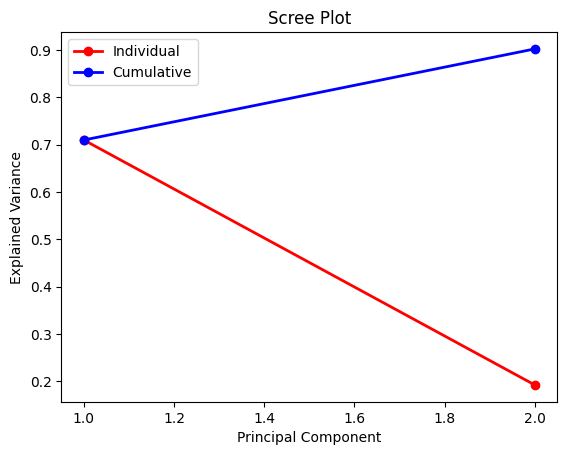

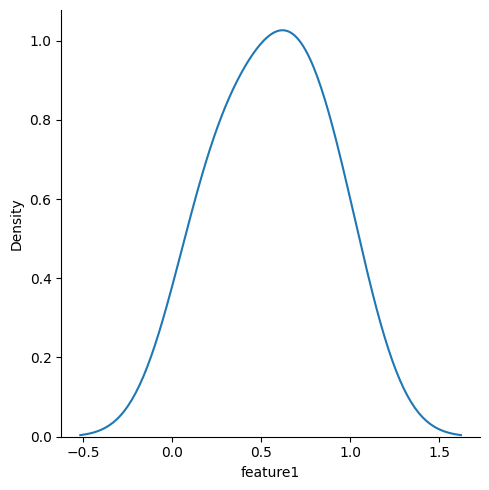

   color  feature1  feature2     value    target  colorLabel  colorFrequency  \
0    Red  0.374540  0.155995  0.020584  0.183405           2               2   
1   Blue  0.950714  0.058084  0.969910  0.304242           0               2   
2  Green  0.731994  0.866176  0.832443  0.524756           1               1   
3   Blue  0.598658  0.601115  0.212339  0.431945           0               2   
4    Red  0.156019  0.708073  0.181825  0.291229           2               2   

   rollingMean  rollingStd  
0     0.443420    0.426952  
1     0.443420    0.426952  
2     0.607646    0.513035  
3     0.671564    0.403596  
4     0.408869    0.367143  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
data = {
    'color': ['Red', 'Blue', 'Green', 'Blue', 'Red'],
    'feature1': np.random.rand(5),
    'feature2': np.random.rand(5),
    'value': np.random.rand(5)
}
df = pd.DataFrame(data)
df['target'] = np.random.rand(len(df))
df['colorLabel'] = df['color'].map({'Blue':0, 'Green':1, 'Red':2})
df['colorFrequency'] = df['color'].map(df['color'].value_counts())
encodedDf = pd.get_dummies(df, columns=['color'], drop_first=False)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
polyFeatures = poly.fit_transform(df[['feature1', 'feature2']])
df['rollingMean'] = df['value'].rolling(window=3).mean().fillna(df['value'].mean())
df['rollingStd'] = df['value'].rolling(window=3).std().fillna(df['value'].std())
numericalDf = df.drop(columns=['color'])
X = numericalDf.drop(columns=['target'])
y = numericalDf['target']
Xnew = SelectKBest(f_regression, k='all').fit_transform(X, y)
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)
rf = RandomForestRegressor()
rf.fit(X, y)
pca = PCA(n_components=2)
Xpca = pca.fit_transform(X)
PCvalues = np.arange(pca.n_components_) + 1
plt.plot(PCvalues, pca.explained_variance_ratio_, 'ro-', linewidth=2, label='Individual')
plt.plot(PCvalues, pca.explained_variance_ratio_.cumsum(), 'bo-', linewidth=2, label='Cumulative')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.legend()
plt.show()
sns.displot(df, x="feature1", kind="kde")
plt.show()
print(df)